# Real-Time Gesture Typing - Model Training

This notebook is used for experimentation, including dataset exploration, preprocessing, data augmentation, and model training.

The final implementation of the project is organized in standalone Python scripts (`.py`), which use the trained model for real-time gesture recognition.

## Imports

In [47]:
import os
from keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Import Dataset

In [48]:

# pasta base com subpastas A, B, C, ...
base_folder = "./data/asl_alphabet_train"

# dataset de treino (80%) e validação (20%)
batch_size = 64
img_size = [128, 128]

ds_train_ = tf.keras.utils.image_dataset_from_directory(
    base_folder,
    labels='inferred',          # labels vêm das subpastas
    label_mode='categorical',   # 29 classes → one-hot
    validation_split=0.2,       # 20% validação
    subset="training",
    seed=42,                    # para divisão reproducível
    image_size=img_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

ds_valid_ = tf.keras.utils.image_dataset_from_directory(
    base_folder,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 87000 files belonging to 29 classes.
Using 69600 files for training.
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.


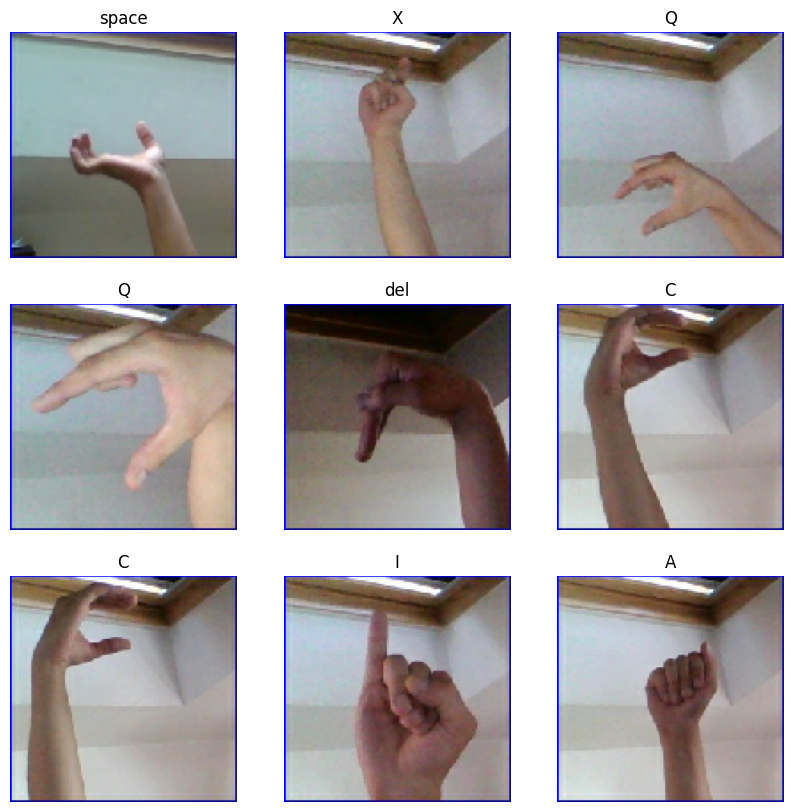

In [49]:
class_names = ds_train_.class_names  # lista de nomes das classes

for images, labels in ds_train.take(1):
    images = tf.clip_by_value(images, 0.0, 1.0)  # garante que matplotlib não queixa
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        label_index = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_index])  # mostra o nome da classe
        plt.axis("off")
    plt.show()
    break

## Data Augmentation

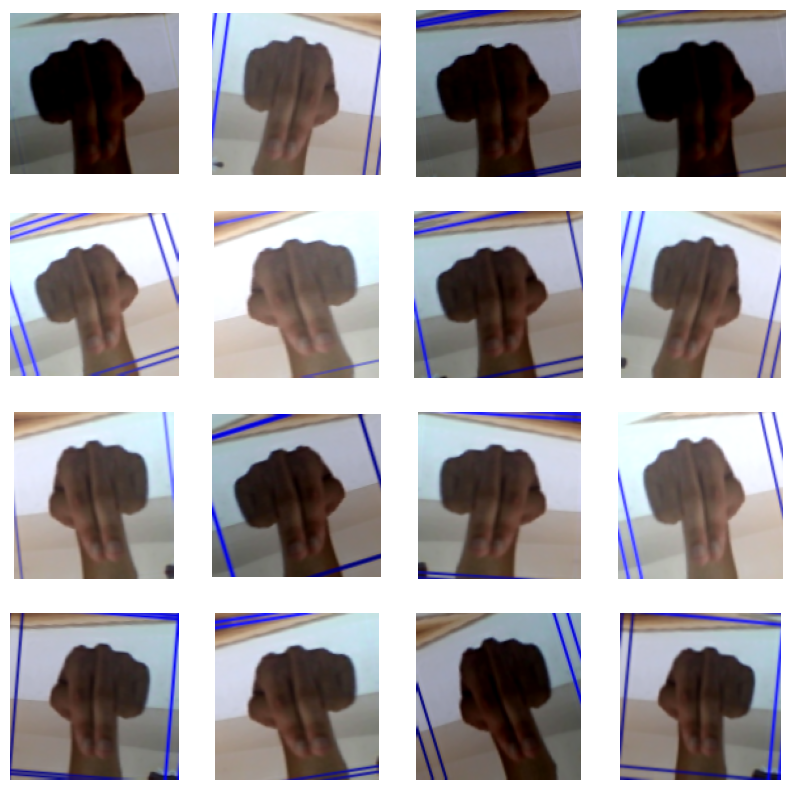

In [50]:
augment = keras.Sequential([
    layers.RandomContrast(factor=0.2),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.001),
    #layers.RandomSaturation(factor=0.002),
    layers.RandomFlip(mode='horizontal'), # meaning, left-to-right
    #layers.RandomFlip(mode='vertical'), # meaning, top-to-bottom
    layers.RandomWidth(factor=0.05), # horizontal stretch
    layers.RandomRotation(factor=0.05),
    layers.RandomTranslation(height_factor=0.01, width_factor=0.01),
])


ex = next(iter(ds_train.unbatch().map(lambda x, y: x).batch(1)))

plt.figure(figsize=(10,10))
for i in range(16):
    image = augment(ex, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)  # força 0..1
    plt.subplot(4, 4, i+1)
    plt.imshow(tf.squeeze(image))
    plt.axis('off')
plt.show()

## Model Layers

In [ ]:
model = keras.Sequential([
    layers.InputLayer(shape = [128, 128, 3]),

    #Data Augmentation
    layers.RandomContrast(factor=0.2),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.001),
    layers.RandomFlip(mode='horizontal'), # meaning, left-to-right
    layers.RandomWidth(factor=0.05), # horizontal stretch
    layers.RandomRotation(factor=0.05),
    layers.RandomTranslation(height_factor=0.01, width_factor=0.01),

    #Layers of NN
    #Block 1
    layers.BatchNormalization(),
    layers.Conv2D(
        filters=64,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.MaxPool2D(),

    #Block 2
    layers.BatchNormalization(),
    layers.Conv2D(
        filters=128,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.MaxPool2D(),    
    
    #Block 3
    layers.BatchNormalization(),
    layers.Conv2D(
        filters=256,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.Conv2D(
        filters=256,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.MaxPool2D(),

    #Dense layers - Head
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.2),
    layers.Dense(29,activation='softmax', kernel_regularizer=regularizers.l2(0.0005))


])

In [51]:
optimizer = tf.keras.optimizers.Adam(epsilon=0.01)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        #Precision(name='precision'),
        #Recall(name='recall')
    ]
)


In [52]:
small_ds_train = ds_train.take(430)  # test the model with 430 batches (27520 images, 40% of train) 
small_ds_valid = ds_valid.take(108)   # validation with 40% of the validation set (6912 images)

model.fit(
    small_ds_train,
    validation_data=small_ds_valid,
    epochs=10
)

Epoch 1/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1385s 3s/step - accuracy: 0.1283 - loss: 3.1491 - val_accuracy: 0.0000e+00 - val_loss: 3.3050
Epoch 2/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1458s 3s/step - accuracy: 0.3051 - loss: 2.4142 - val_accuracy: 0.1415 - val_loss: 2.6508
Epoch 3/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1386s 3s/step - accuracy: 0.4677 - loss: 1.7949 - val_accuracy: 0.3683 - val_loss: 2.1477
Epoch 4/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1378s 3s/step - accuracy: 0.5972 - loss: 1.3706 - val_accuracy: 0.5181 - val_loss: 1.7547
Epoch 5/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1374s 3s/step - accuracy: 0.7027 - loss: 1.0635 - val_accuracy: 0.6221 - val_loss: 1.2446
Epoch 6/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1363s 3s/step - accuracy: 0.7757 - loss: 0.8550 - val_accuracy: 0.8584 - val_loss: 0.7566
Epoch 7/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1369s 3s/step - accuracy: 0.8319 - loss: 0.7069 - val_accuracy: 0.7611 - val_loss: 0.8778
Epoch 8/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 1362s 3s/step - accuracy: 0.8672 - loss: 0.598

## Test model

In [53]:
import numpy as np
# pasta base com subpastas A, B, C, ...
test_folder = "./data/asl_alphabet_test"


class_names = ds_train_.class_names

X = []
y = []

for file in os.listdir(test_folder):
    if file.endswith(".jpg"):
        # label: "A_test.jpg" -> "A"
        label = file.split("_")[0]

        # imagem
        img = load_img(os.path.join(test_folder, file), target_size=img_size)
        img = img_to_array(img) / 255.0

        X.append(img)
        y.append(class_names.index(label))

X = np.array(X)
y = np.array(y)
len(X), len(y)

(29, 29)

In [54]:
preds = model.predict(X)
pred_classes = np.argmax(preds, axis=1)

for i in range(len(X)):
    print(f"Real: {class_names[y[i]]} | Pred: {class_names[pred_classes[i]]}")

accuracy = np.mean(pred_classes == y)
print(f"Test Accuracy: {accuracy:.2%} -> {len(np.where(pred_classes == y)[0])}/{len(y)} right")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
Real: A | Pred: A
Real: B | Pred: B
Real: C | Pred: C
Real: del | Pred: del
Real: D | Pred: D
Real: E | Pred: E
Real: F | Pred: F
Real: G | Pred: G
Real: H | Pred: H
Real: I | Pred: I
Real: J | Pred: J
Real: K | Pred: K
Real: L | Pred: L
Real: M | Pred: M
Real: nothing | Pred: nothing
Real: N | Pred: N
Real: O | Pred: O
Real: P | Pred: P
Real: Q | Pred: Q
Real: R | Pred: X
Real: space | Pred: space
Real: S | Pred: S
Real: T | Pred: T
Real: U | Pred: X
Real: V | Pred: V
Real: W | Pred: W
Real: X | Pred: X
Real: Y | Pred: Y
Real: Z | Pred: X
Test Accuracy: 89.66% -> 26/29 right


In [58]:
model.save("models/test_model_v2.keras")

In [59]:
with open("experiments_log.txt", "a") as f:
    f.write("""
==============================
Model: test_model_v2
- img_size: 128
- batch_size: 64
- initializer: he_normal
- augmentation: Contrast(0.2), Zoom(0.1/0.1), Brightness(0.001), Flip('horizontal'), Width(0.05), Rotation(0.05),Translation(0.01/0.01)
- model: 3 blocks conv2d + head dense (batchnorm, GAP, dense 64 + dropout 20%, dense 29)
- result: acc=0.9189  loss=0.4677 / val_acc=0.9654  val_loss=0.3527
- prediction: 89.66% -> 26/29 right
- notes: 
        This model was trained with 40% of the training data and validated with 40% of the validation data, and only 10 epochs.
        After 10 epochs of training, the model achieved an accuraçy of 91.89% and loss of 0.4677 on training and 96.54% accuracy and loss of 0.3527 on validation.
        This model was used as a sanity check to verify that the model architecture (especially the data augmentation) was functioning correctly, and was not intended for performance evaluation, although it showed promising results.
            
==============================
""")

In [61]:
modelo = tf.keras.models.load_model("models/test_model_v2.keras")
#modelo.get_weights()
